## Bibliotekos

In [1]:
library(dplyr)
library(ggplot2)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Duomenys

In [2]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset.csv"), sep = ',')
data$observationTime <- as.Date(data$observationTime)
dim(data)

[1] 2772   31

In [3]:
head(data)

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,⋯,t2m,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,-1.0162473,7.533331e-05,6.183662e-05,0.0001933129,22057.93,1136.782,4.376100e+13,1.489699e+13,3.627587e+15,⋯,12.97028,11.29583,1010.638,72.79167,9.1,89.37500,10.93333,3.762500,13.9,356
2,2018-07-02,-0.8006216,7.926575e-05,6.572057e-05,0.0001963793,22067.76,1229.532,3.946727e+13,1.611675e+13,3.795988e+15,⋯,14.77985,10.86667,1006.663,94.00000,11.9,91.50000,10.42917,2.516667,7.0,327
3,2018-07-03,-0.6212348,7.699571e-05,6.164219e-05,0.0002032877,19219.67,1314.681,4.465846e+13,1.499280e+13,4.526218e+15,⋯,15.96597,13.38750,1008.454,90.04167,10.0,89.37500,13.38750,2.537500,8.3,271
4,2018-07-04,-0.6591799,7.192521e-05,6.535854e-05,0.0001463974,19219.45,1824.428,4.888972e+13,1.430855e+13,4.149200e+15,⋯,18.01572,13.59167,1009.237,88.29167,13.9,88.33333,13.59167,2.358333,8.7,288
5,2018-07-05,-1.0102344,7.921198e-05,6.705435e-05,0.0001983014,19218.37,1257.064,4.093649e+13,1.583584e+13,3.959891e+15,⋯,19.04031,16.29167,1008.079,70.20833,0.0,66.00000,16.29167,1.283333,6.1,293
6,2018-07-06,-1.1754774,8.286563e-05,6.885977e-05,0.0001936762,19223.54,1455.858,2.298473e+13,1.981660e+13,3.959520e+15,⋯,19.61520,17.68750,1008.171,68.16667,0.0,51.33333,17.68750,3.108333,10.4,275


## Išskirčių analizė

### Tsoutliers paketas

In [ ]:
install.packages('tsoutliers')

Installing package into 'C:/Users/eveli/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



In [ ]:
library(tsoutliers)

outlier_analysis <- tso(ts(data_clean$xgb_precipitation))

print(outlier_analysis)
plot(outlier_analysis)

Warning message in locate.outliers.iloop(resid = resid, pars = pars, cval = cval, :
"stopped when 'maxit.iloop' was reached"
Warning message in locate.outliers.oloop(y = y, fit = fit, types = types, cval = cval, :
"stopped when 'maxit.oloop = 4' was reached"


: 

### Išskirčių skaičius pagal tarpkvartilinį plotą

In [4]:
count_outliers_IQR <- function(data, var_name) {
  data %>%
    summarise(
      variable = var_name,
      Q1 = quantile(.data[[var_name]], 0.25),
      Q3 = quantile(.data[[var_name]], 0.75),
      H = Q3 - Q1,
      outer_low = Q1 - 3*H,
      outer_high = Q3 + 3*H,
      IQR_extreme_outliers = sum(.data[[var_name]] < outer_low | .data[[var_name]] > outer_high)
      )
}

In [5]:
numeric_cols <- data %>% 
  dplyr::select(where(is.numeric)) %>% 
  names()

results_list_full <- lapply(numeric_cols, function(col) count_outliers_IQR(data, col))
IQR_outlier_summary_full <- bind_rows(results_list_full)
IQR_outlier_summary_full

variable,Q1,Q3,H,outer_low,outer_high,IQR_extreme_outliers
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
absorbing_aerosol_index,-1.138378e+00,-2.884844e-01,8.498935e-01,-3.688059e+00,2.261196e+00,2
NO2_column_number_density,6.528396e-05,8.654637e-05,2.126241e-05,1.496742e-06,1.503336e-04,61
stratospheric_NO2_column_number_density,2.524213e-05,5.749933e-05,3.225720e-05,-7.152948e-05,1.542709e-04,0
NO2_slant_column_number_density,1.533367e-04,1.924995e-04,3.916279e-05,3.584832e-05,3.099879e-04,3
tropopause_pressure,1.667883e+04,1.926195e+04,2.583122e+03,8.929463e+03,2.701132e+04,10
H2O_column_number_density,4.747029e+02,1.351585e+03,8.768822e+02,-2.155944e+03,3.982232e+03,6
BrO,3.399393e+13,4.762002e+13,1.362609e+13,-6.884342e+12,8.849830e+13,0
BrO_Error,1.435706e+13,1.975258e+13,5.395520e+12,-1.829500e+12,3.593914e+13,1
NO2,1.722114e+15,3.463748e+15,1.741634e+15,-3.502789e+15,8.688651e+15,0


### Išskirčių skaičius pagal tarpkvartilinį plotą išfiltravus KRITULIŲ nulius

In [6]:
data_without_zeros <- data %>%
  filter(missforest_precipitation>0)

results_list_0 <- lapply(numeric_cols, function(col) count_outliers_IQR(data_without_zeros, col))
IQR_outlier_summary_0 <- bind_rows(results_list_0)
IQR_outlier_summary_0

variable,Q1,Q3,H,outer_low,outer_high,IQR_extreme_outliers
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
absorbing_aerosol_index,-1.089875e+00,-2.876503e-01,8.022246e-01,-3.496549e+00,2.119024e+00,1
NO2_column_number_density,6.263069e-05,8.777571e-05,2.514502e-05,-1.280437e-05,1.632108e-04,22
stratospheric_NO2_column_number_density,2.337886e-05,5.655355e-05,3.317469e-05,-7.614519e-05,1.560776e-04,0
NO2_slant_column_number_density,1.514814e-04,1.929627e-04,4.148124e-05,2.703770e-05,3.174064e-04,3
tropopause_pressure,1.668416e+04,2.204767e+04,5.363507e+03,5.936380e+02,3.813819e+04,0
H2O_column_number_density,4.438601e+02,1.234945e+03,7.910853e+02,-1.929396e+03,3.608201e+03,5
BrO,3.642269e+13,4.924590e+13,1.282321e+13,-2.046935e+12,8.771553e+13,0
BrO_Error,1.364003e+13,1.768850e+13,4.048468e+12,1.494631e+12,2.983391e+13,1
NO2,1.569271e+15,3.372079e+15,1.802808e+15,-3.839154e+15,8.780503e+15,0


## Vizualizacija

In [7]:
identify_outliers <- function(data, var_name) {
    stats <- data %>%
        summarise(
            Q1 = quantile(.data[[var_name]], 0.25),
            Q3 = quantile(.data[[var_name]], 0.75),
            H = Q3 - Q1) %>%
        mutate(
            outer_low = Q1 - 3 * H,
            outer_high = Q3 + 3 * H)

    data %>%
        mutate(
            is_outlier = ifelse((.data[[var_name]] < stats$outer_low | .data[[var_name]] > stats$outer_high), 1, 0))
}

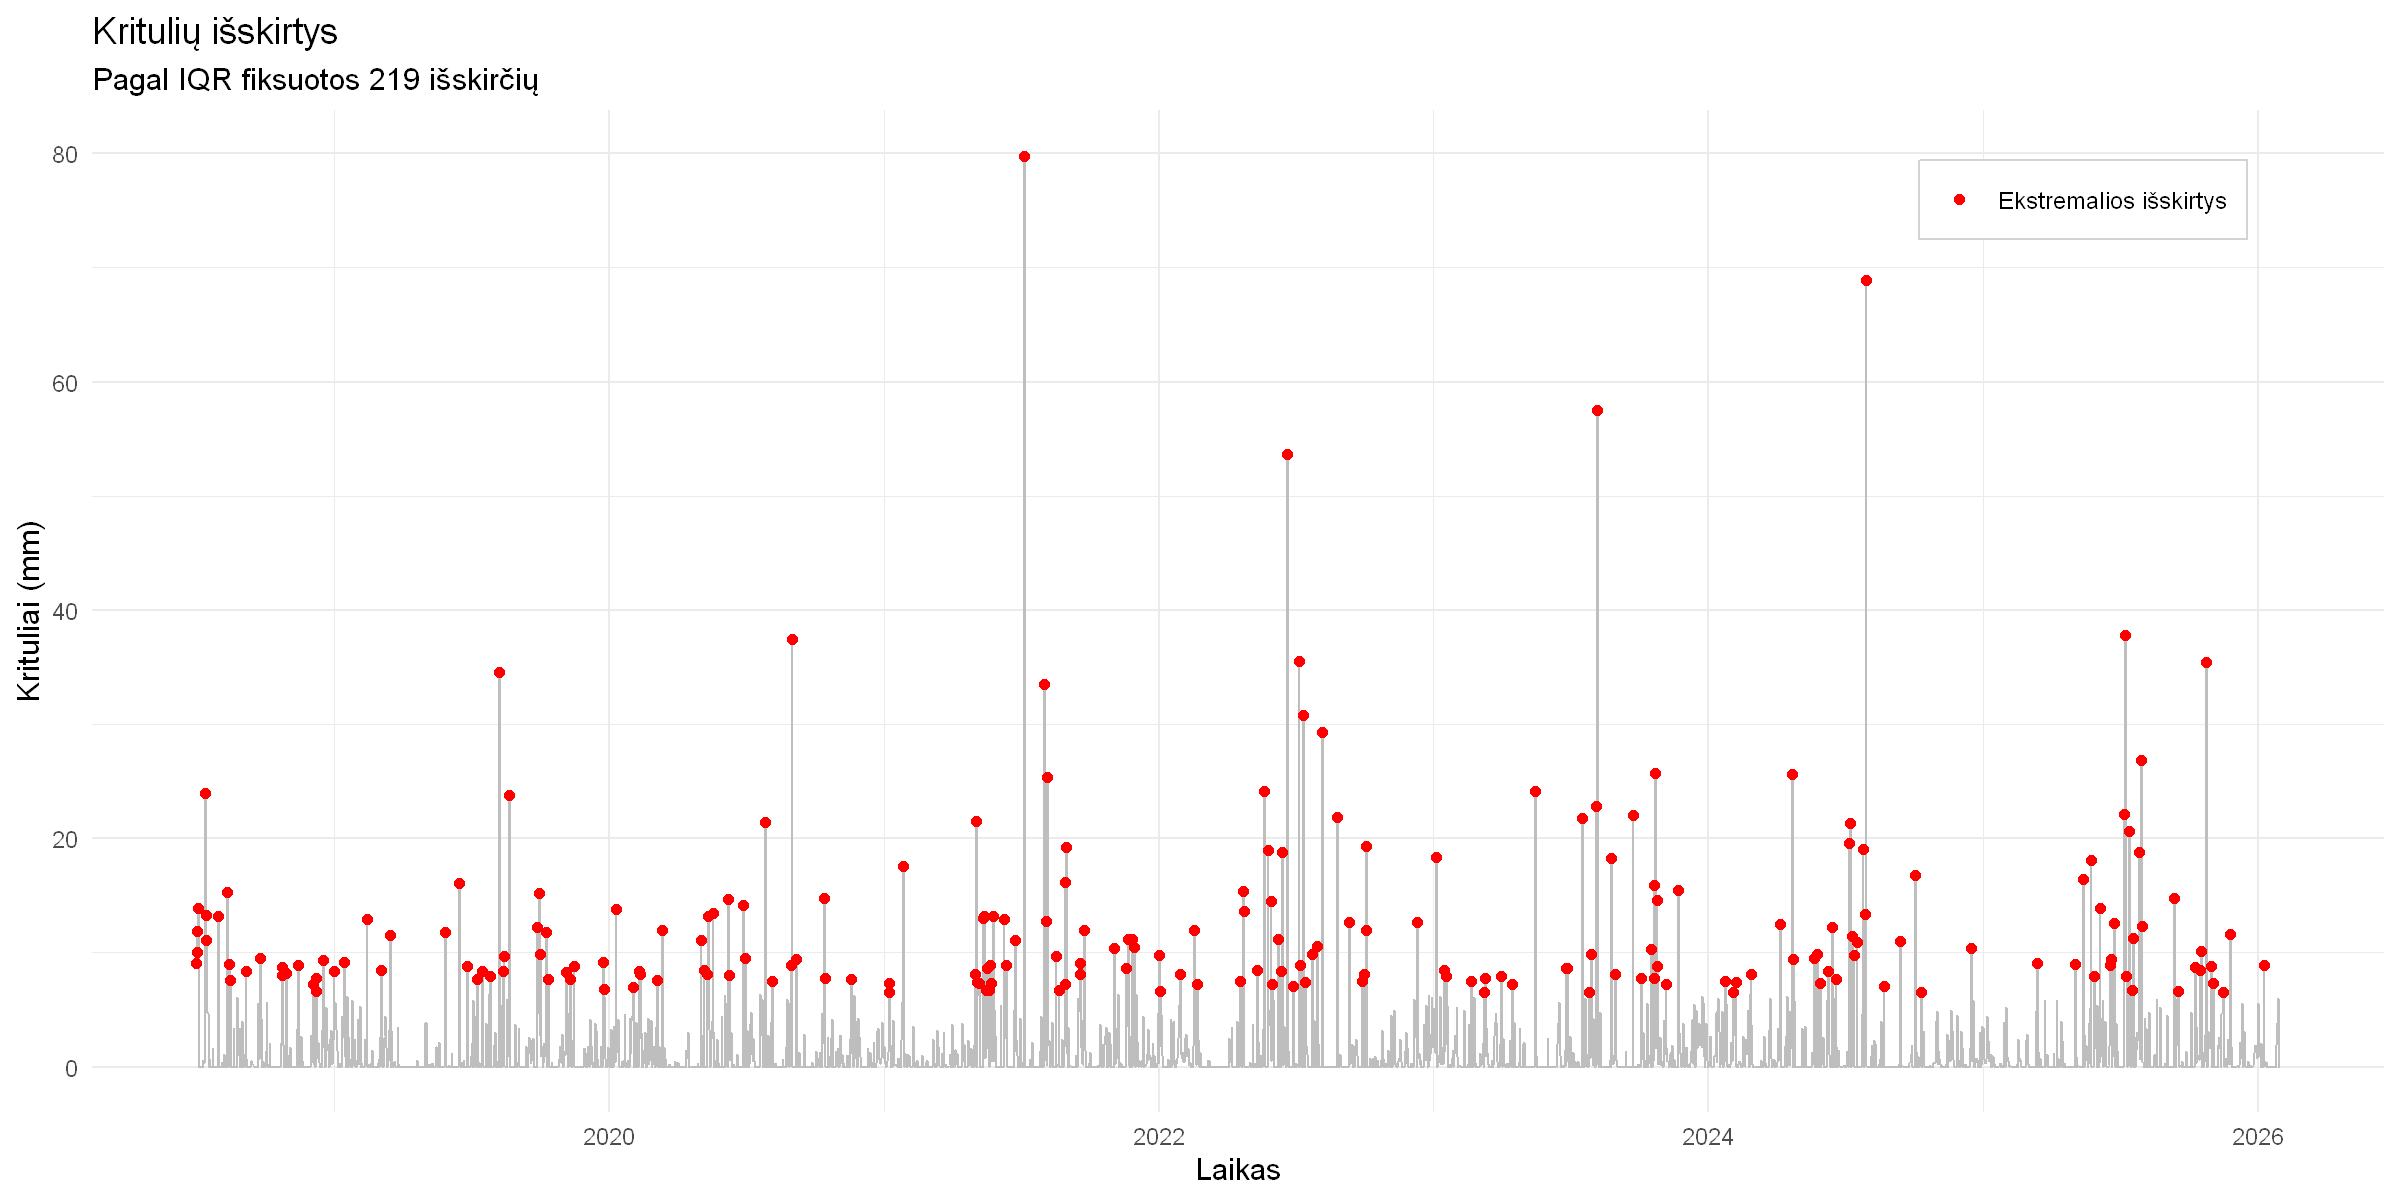

In [8]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

data_with_outliers <- identify_outliers(data, 'missforest_precipitation')

ggplot(data_with_outliers, aes(x = observationTime, y = missforest_precipitation, color = as.factor(is_outlier))) +
  geom_line(color = 'grey') +
  geom_point(data = subset(data_with_outliers, is_outlier == 1), 
             aes(color = as.factor(is_outlier))) +
  scale_color_manual(values = c("1" = "red"),
                     labels = c("Ekstremalios išskirtys")) +
  theme_minimal() +
  theme(legend.position = c(0.94, 0.95), legend.justification = c("right", "top"), 
        legend.background = element_rect(fill = "white", color = "lightgrey"), legend.title = element_blank()) +
  labs(title = "Kritulių išskirtys", , subtitle = "Pagal IQR fiksuotos 219 išskirčių", x = "Laikas", y = "Krituliai (mm)")

In [9]:
data_with_outliers <- identify_outliers(data_without_zeros, 'missforest_precipitation')

data_plot_extreme_outliers <- data %>%
  left_join(data_with_outliers %>% select(observationTime, is_outlier), by = "observationTime")

data_plot_extreme_outliers$is_outlier[is.na(data_plot_extreme_outliers$is_outlier)] <- 0

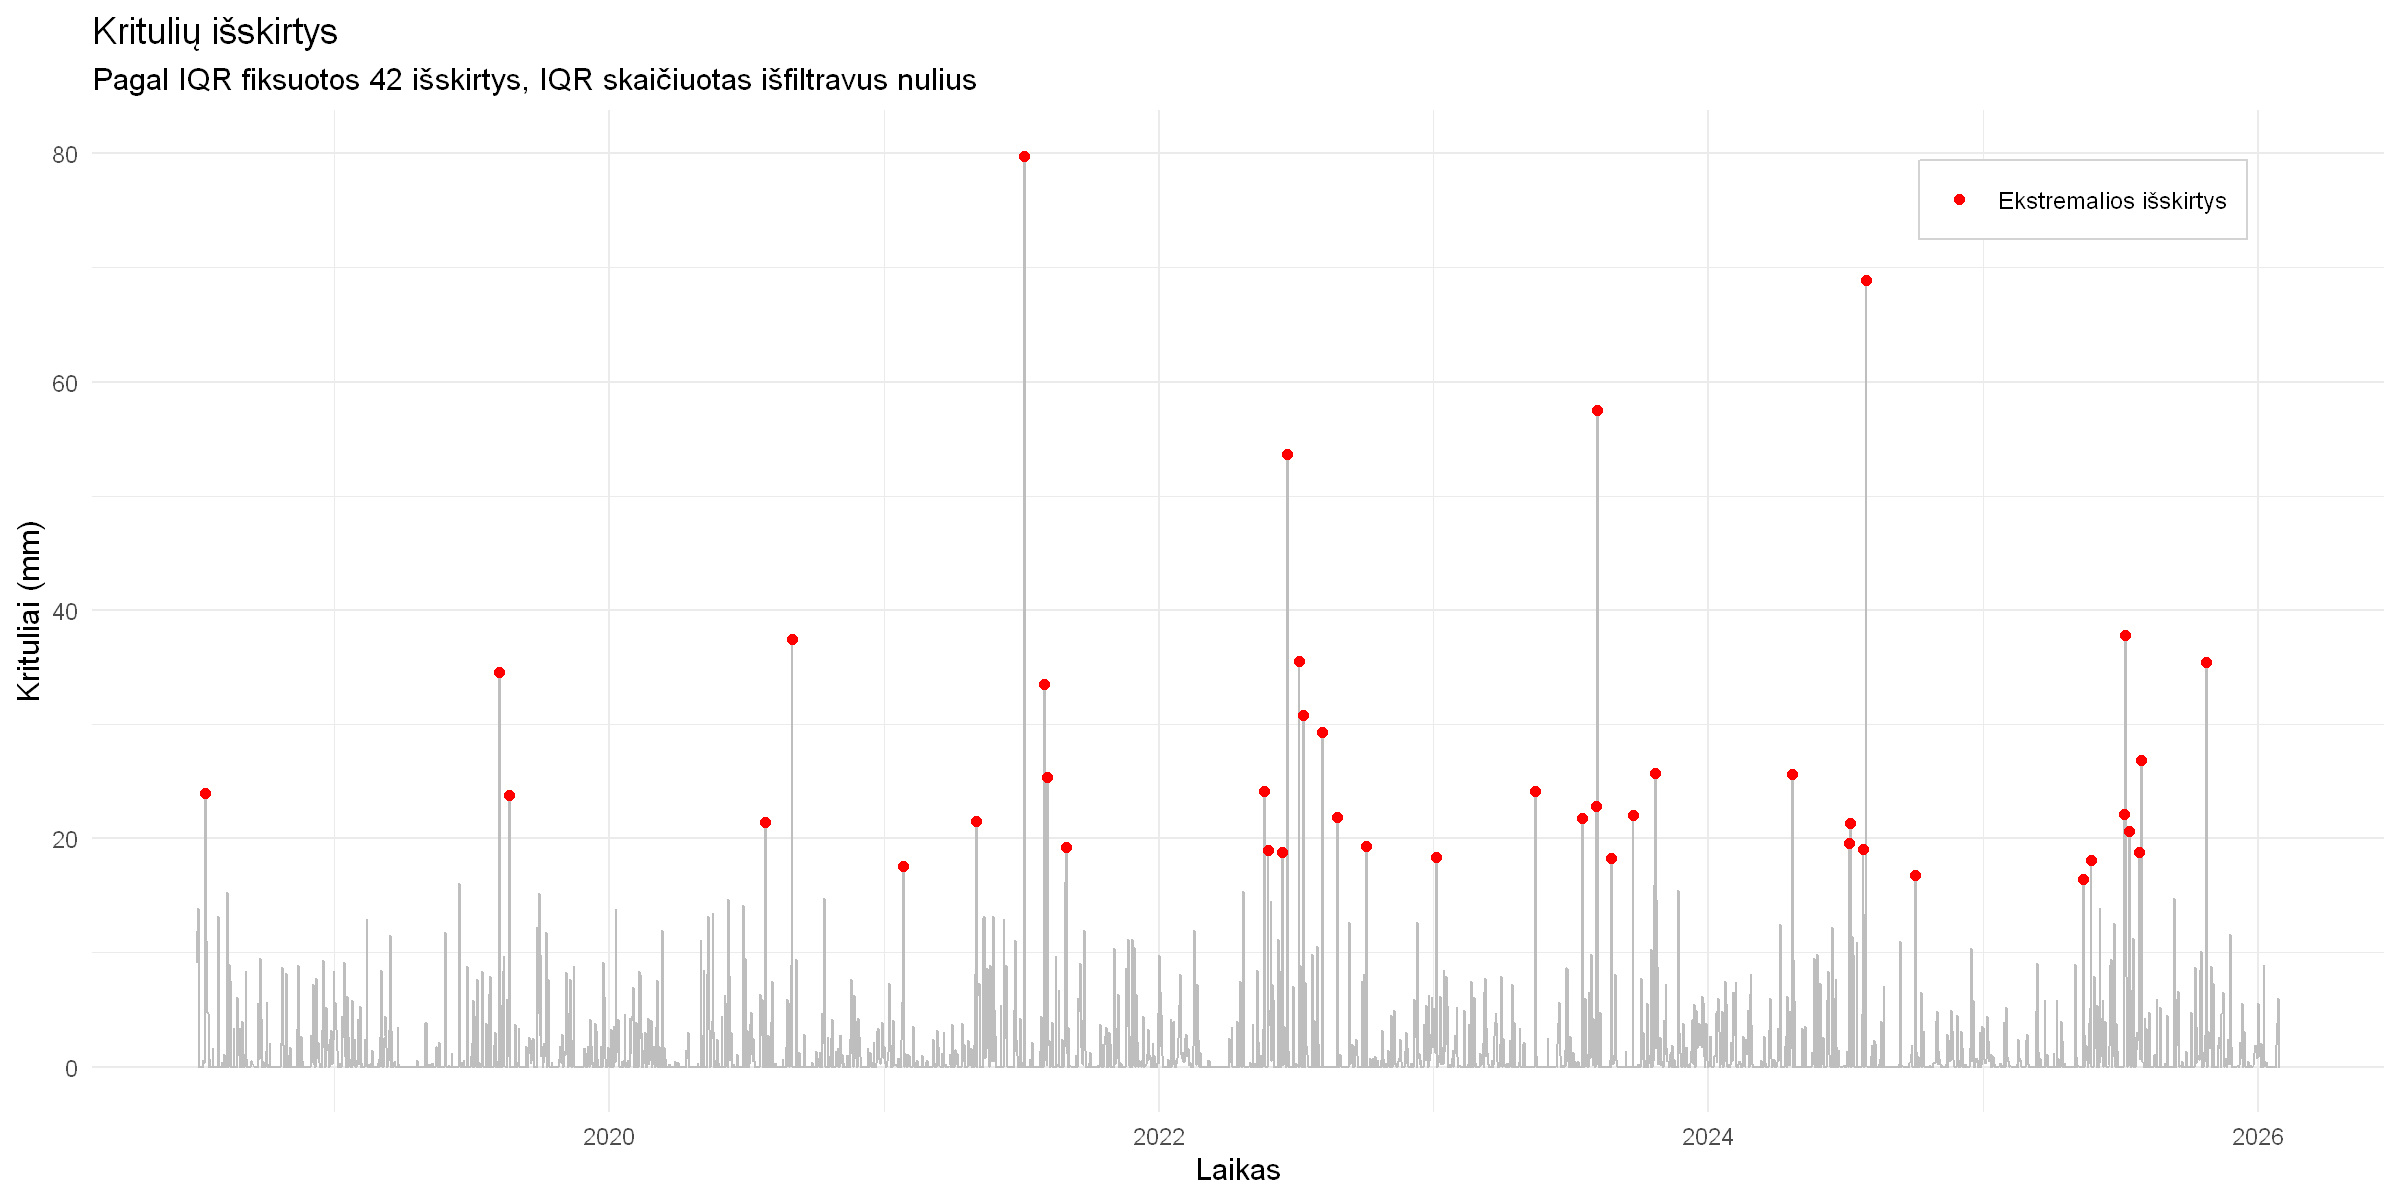

In [10]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

ggplot(data_plot_extreme_outliers, aes(x = observationTime, y = missforest_precipitation, color = as.factor(is_outlier))) +
  geom_line(color = 'grey') +
  geom_point(data = subset(data_plot_extreme_outliers, is_outlier == 1), aes(color = as.factor(is_outlier))) +
  scale_color_manual(values = c("1" = "red"), labels = c("Ekstremalios išskirtys")) +
  theme_minimal() +
  theme(legend.position = c(0.94, 0.95), legend.justification = c("right", "top"), 
        legend.background = element_rect(fill = "white", color = "lightgrey"), legend.title = element_blank()) +
  labs(title = "Kritulių išskirtys", subtitle = "Pagal IQR fiksuotos 42 išskirtys, IQR skaičiuotas išfiltravus nulius",  x = "Laikas", y = "Krituliai (mm)")

## Daugiamatės išskirtys

### Skaičiuojama pagal kiek požymių stebėjimas laikomas išskirtimi

In [11]:
check_bounds <- function(x, col_name, info) {
  limits <- info[info$variable == col_name, ]
  as.integer(x < as.numeric(limits$outer_low) | x > as.numeric(limits$outer_high))
}

In [12]:
data_outlier_info <- data %>%
  mutate(across(all_of(numeric_cols), ~ check_bounds(.x, cur_column(), IQR_outlier_summary_full), .names = "is_out_by_{.col}"))

data_outlier_info <- data_outlier_info %>%
  mutate(outlier_dim = rowSums(across(starts_with("is_out_by_")), na.rm = TRUE)) %>%
  arrange(desc(outlier_dim))

data_outlier_info <- data_outlier_info %>%
  mutate(is_outlier = as.integer(outlier_dim > 1) )

In [13]:
outliers_4 <- data_outlier_info %>% 
  filter(outlier_dim == 4)

nrow(outliers_4)
outliers_4

[1] 6

observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,⋯,is_out_by_seaLevelPressure,is_out_by_relativeHumidity,is_out_by_missforest_precipitation,is_out_by_xgb_cloudCover,is_out_by_feelsLikeTemperature_fixed,is_out_by_windSpeed_fixed,is_out_by_windGust_fixed,is_out_by_windDirection_fixed,outlier_dim,is_outlier
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
2019-02-18,-1.05824840,1.142976e-04,2.688001e-05,0.0002334135,16678.64,476.4758,5.920424e+13,1.472421e+13,1.802209e+15,⋯,0,0,0,0,0,0,0,0,4,1
2019-10-24,-0.24535290,6.530595e-05,3.009092e-05,0.0002281634,13051.25,818.4583,3.477979e+13,2.287270e+13,2.375305e+15,⋯,0,0,0,0,0,0,0,0,4,1
2021-02-22,0.35716927,1.416063e-04,2.614483e-05,0.0001797862,16701.00,784.3584,3.128807e+13,1.585218e+13,2.473832e+15,⋯,0,0,0,0,0,0,0,0,4,1
2025-03-07,-0.06089796,5.464690e-05,2.293775e-05,0.0001354573,16688.32,414.0516,3.332555e+13,1.667581e+13,1.568237e+15,⋯,0,0,0,0,0,0,0,0,4,1
2025-03-10,0.05797799,6.777272e-05,2.257257e-05,0.0001291747,16660.23,946.5724,4.521075e+13,1.863672e+13,1.627183e+15,⋯,0,0,0,0,0,0,0,0,4,1
2025-03-11,-0.00178808,5.470057e-05,2.387589e-05,0.0001312172,19200.46,364.3550,4.174364e+13,1.703115e+13,1.636396e+15,⋯,0,0,0,0,0,0,0,0,4,1


In [14]:
outliers_3 <- data_outlier_info %>% 
  filter(outlier_dim == 3)

nrow(outliers_3)
outliers_3

[1] 13

observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,⋯,is_out_by_seaLevelPressure,is_out_by_relativeHumidity,is_out_by_missforest_precipitation,is_out_by_xgb_cloudCover,is_out_by_feelsLikeTemperature_fixed,is_out_by_windSpeed_fixed,is_out_by_windGust_fixed,is_out_by_windDirection_fixed,outlier_dim,is_outlier
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
2018-09-05,-0.7271913,8.007614e-05,4.941699e-05,0.0001910575,16684.18,1230.7935,4.122291e+13,1.412435e+13,2.623827e+15,⋯,0,0,1,0,0,0,0,0,3,1
2019-04-25,-0.9781353,7.592452e-05,4.872322e-05,0.0001850219,16683.92,1157.3015,3.956056e+13,1.747564e+13,4.083764e+15,⋯,0,0,0,0,0,0,0,0,3,1
2019-04-26,-0.9954218,7.161577e-05,4.625398e-05,0.0001722708,16675.49,1312.5225,2.890197e+13,1.704984e+13,3.259947e+15,⋯,0,0,0,0,0,0,0,0,3,1
2020-06-08,-1.4691480,7.753804e-05,5.665955e-05,0.0001843668,16681.76,2380.3098,4.479996e+13,2.459041e+13,3.639417e+15,⋯,0,0,1,0,0,0,0,0,3,1
2021-03-25,-1.6149839,7.031552e-05,4.574793e-05,0.0001774050,19248.43,553.8904,5.454856e+13,1.629300e+13,2.263092e+15,⋯,0,0,0,0,0,0,0,0,3,1
2021-06-22,-1.2753003,8.935202e-05,6.205232e-05,0.0001998644,14417.55,2645.6270,2.902327e+13,1.854711e+13,3.983592e+15,⋯,0,0,0,0,0,0,0,0,3,1
2022-08-21,-0.7863731,7.453516e-05,5.953634e-05,0.0001615456,14416.92,1817.4005,3.436162e+13,1.514980e+13,3.457060e+15,⋯,0,0,0,0,0,0,0,0,3,1
2022-08-22,0.4591557,8.026154e-05,6.017739e-05,0.0002131071,14418.36,1796.7239,3.335730e+13,2.266989e+13,3.622867e+15,⋯,0,0,0,0,0,0,0,0,3,1
2022-12-11,-1.7748785,1.645567e-04,2.433302e-05,0.0003245298,19186.82,453.9670,3.505580e+13,1.179812e+13,1.381767e+15,⋯,0,0,1,0,0,0,0,0,3,1


In [15]:
outliers_2 <- data_outlier_info %>% 
  filter(outlier_dim == 2)

nrow(outliers_2)
head(outliers_2)

[1] 79

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,⋯,is_out_by_seaLevelPressure,is_out_by_relativeHumidity,is_out_by_missforest_precipitation,is_out_by_xgb_cloudCover,is_out_by_feelsLikeTemperature_fixed,is_out_by_windSpeed_fixed,is_out_by_windGust_fixed,is_out_by_windDirection_fixed,outlier_dim,is_outlier
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,2018-07-01,-1.016247323,7.533331e-05,6.183662e-05,0.0001933129,22057.93,1136.7820,4.376100e+13,1.489699e+13,3.627587e+15,⋯,0,0,1,0,0,0,0,0,2,1
2,2018-07-13,-1.214122700,8.436423e-05,6.511252e-05,0.0002075942,19219.33,2178.9436,3.610126e+13,1.652258e+13,3.688520e+15,⋯,0,0,1,0,0,0,0,0,2,1
3,2018-07-14,-0.762475970,7.858760e-05,6.294364e-05,0.0002031836,19222.88,2346.3391,3.659979e+13,1.520030e+13,4.186392e+15,⋯,0,0,1,0,0,0,0,0,2,1
4,2018-07-27,-0.926320000,8.042006e-05,6.440750e-05,0.0002057823,16681.71,2549.9458,3.185260e+13,1.755338e+13,3.789507e+15,⋯,0,0,0,0,0,0,0,0,2,1
5,2018-11-07,0.008110434,5.400251e-05,2.411821e-05,0.0001829236,14420.56,732.2108,3.900528e+13,1.083612e+13,1.634459e+15,⋯,0,0,0,0,0,0,0,0,2,1
6,2018-12-07,-0.826313500,4.994480e-04,1.149323e-05,0.0001552871,19197.96,550.9184,4.215751e+13,1.016133e+13,9.116093e+14,⋯,0,0,1,0,0,0,0,0,2,1
